# Click-through-rate prediction
Objective: predict CTR based on TaoBao's datasets.<br>
Motivation: In online advertising systems, CTR prediction is the backbone of auction mechanism and used to decide which advertisement should be displayed to users, how much the advertisers should be charged, etc.<br>
[Link to datasets](https://tianchi.aliyun.com/dataset/56?spm=a2c22.12282016.0.0.27932e70F6FmRS)<br>
This notebook contains the following parts:
> 1. Exploratory data analysis
> 2. Preprocessing
> 3. Modeling<br>

In [19]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

In [20]:
# Load datasets
ad_feature = pd.read_csv(
    "/Users/nguyend.anh/Documents/Data analytics learning/Datasets/CTR prediction/ad_feature.csv")
raw = pd.read_csv(
    "/Users/nguyend.anh/Documents/Data analytics learning/Datasets/CTR prediction/raw_sample.csv")
user_profile = pd.read_csv(
    "/Users/nguyend.anh/Documents/Data analytics learning/Datasets/CTR prediction/user_profile.csv")

## 1. Exploratory data analysis

In [21]:
# First look at datasets
raw["time_stamp"] = pd.to_datetime(raw["time_stamp"], unit="s")
display(raw.head(3))
raw["time_stamp"].max()  # '2017-05-13 15:59:46'
raw["time_stamp"].min()  # '2017-05-05 16:00:00'
# I will use the data from 05-05 to 05-12 as train set, and the last day as test set.

# Add hour and day features
raw["day"] = raw["time_stamp"].dt.day
raw["hour"] = raw["time_stamp"].dt.hour

,user,time_stamp,adgroup_id,pid,nonclk,clk
0,581738,2017-05-07 06:14:04,1,430548_1007,1,0
1,449818,2017-05-13 01:26:18,3,430548_1007,1,0
2,914836,2017-05-13 04:47:59,4,430548_1007,1,0


Table name: raw<br>
>(1) user: User ID(int);<br>
>(2) time_stamp: time stamp(Bigint, 1494032110 stands for 2017-05-06 08:55:10);<br>
>(3) adgroup_id: adgroup ID(int);<br>
>(4) pid: scenario;<br>
>(5) noclk: 1 for not click, 0 for click;<br>
>(6) clk: 1 for click, 0 for not click;<br>

In [22]:
# display(ad_feature.head(3))
display(ad_feature.head(3))

,adgroup_id,cate_id,campaign_id,customer,brand,price
0,63133,6406,83237,1,95471.0,170.0
1,313401,6406,83237,1,87331.0,199.0
2,248909,392,83237,1,32233.0,38.0


Table name: ad_feature<br>
This data set covers the basic information of all ads in raw_sample. Field description is as follows:<br>
>(1) adgroup_id：Ad ID(int);<br>
>(2) cate_id：category ID;<br>
>(3) campaign_id：campaign ID;<br>
>(4) brand：brand ID;<br>
>(5) customer: Advertiser ID;<br>
>(6) price: the price of item<br>
One of the ad ID corresponds to an item, an item belongs to a category, an item belongs to a brand.

Number of unique brands: 99814
Number of unique advertisers: 255875
Max: 99999999.0
Min: 0.01
Price 75th percentile: 352.0
Price 25th percentile: 49.0


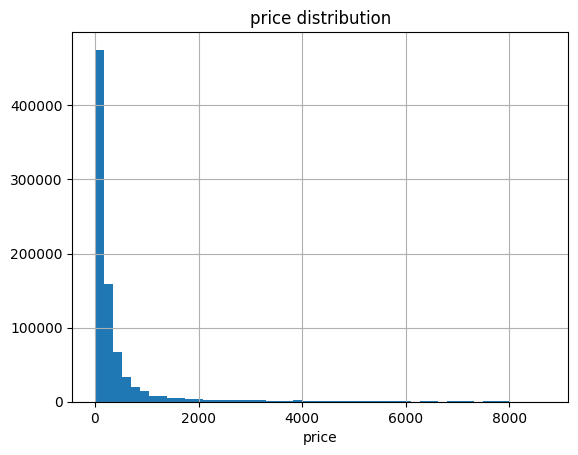

In [23]:
# Some distributions of data in ad_feature table
unique_brand = ad_feature["brand"].nunique()
unique_advertiser = ad_feature["customer"].nunique()
max_price = ad_feature["price"].max()
min_price = ad_feature["price"].min()
p75 = ad_feature["price"].quantile(0.75)
p25 = ad_feature["price"].quantile(0.25)

# Print out values
print(f"Number of unique brands: {unique_brand}")
print(f"Number of unique advertisers: {unique_advertiser}")
print(f"Max: {max_price}")
print(f"Min: {min_price}")
print(f"Price 75th percentile: {p75}")
print(f"Price 25th percentile: {p25}")
# => The price is very stretched across brands with the range from 0.01 (probably in RMB) to 99999999.
# Nonetheless, values like 9999999 are probably outliers that's worth removed (No item on an e-commerce web will reach this kind of price).
# We will remove the 1% highest-priced item for later analysis.
p99 = ad_feature["price"].quantile(0.99)
ad_feature[ad_feature["price"] < p99]["price"].hist(bins=50)
plt.xlabel("price")
plt.title("price distribution")
plt.show()

In [24]:
user_profile.rename(
    columns={'new_user_class_level ': 'new_user_class_level'}, inplace=True)
display(user_profile.head(3))

,userid,cms_segid,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level
0,234,0,5,2,5,NaN,3,0,3.0
1,523,5,2,2,2,1.0,3,1,2.0
2,612,0,8,1,2,2.0,3,0,NaN


Table name: user_profile<br>
This data set covers the basic information of 1060000 users in raw_sample.. Field description is as follows:<br>
>(1) userid: user ID;<br>
>(2) cms_segid: Micro group ID;<br>
>(3) cms_group_id: cms_group_id;<br>
>(4) final_gender_code: gender 1 for male , 2 for female<br>
>(5) age_level: age_level<br>
>(6) pvalue_level: Consumption grade, 1: low,  2: mid,  3: high<br>
>(7) shopping_level: Shopping depth, 1: shallow user, 2: moderate user, 3: depth user<br>
>(8) occupation: Is the college student 1: yes, 0: no?<br>
>(9) new_user_class_level: City level<br>

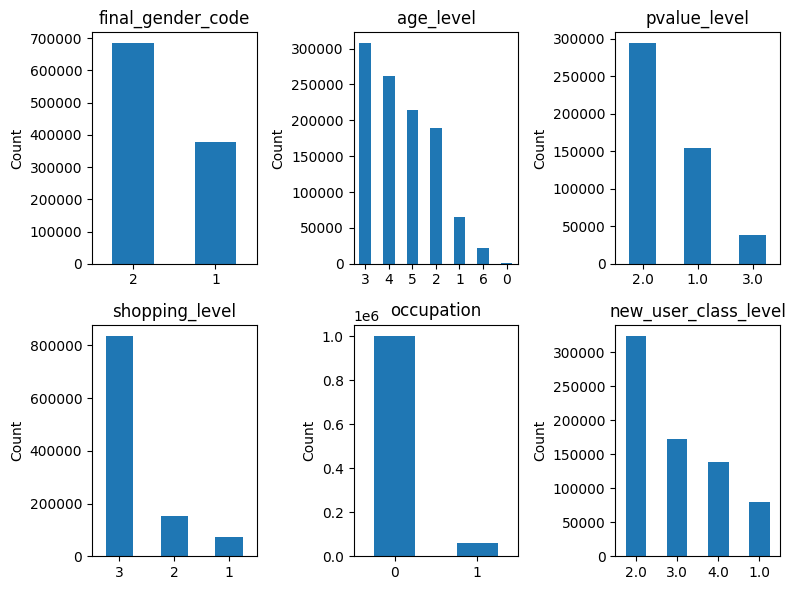

In [25]:
# Distributions of data in user_profile table
# Rename column 'new_user_class_level '
user_profile.rename(
    columns={'new_user_class_level ': "new_user_class_level"}, inplace=True)

user_cols = user_profile.columns[3:]  # Ignore id columns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(user_cols):
    ax = axes[i]
    category_count = user_profile[col].value_counts()
    category_count.plot(kind="bar", ax=ax)

    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 2. Data preprocessing
For logistic regression, the steps are taken as follow:
> 1. Create a table includes all features and dependent variable
> 2. Split data into train, test sets (time-based)
> 3. Remove outliers and standardize numerical column ("price")
> 4. Encode categorical columns
> 5. Resampling

In [26]:
# 1. Create a table includes all features and dependent variable
from_raw = raw[["user", "time_stamp",
                "adgroup_id", "clk", "pid", "hour", "day"]]
from_ad = ad_feature[["adgroup_id", "customer", "brand", "price"]]
from_user = user_profile[["userid", "final_gender_code", "age_level",
                         "pvalue_level", "shopping_level", "occupation", "new_user_class_level"]]

merge1 = pd.merge(from_raw, from_ad, left_on="adgroup_id",
                  right_on="adgroup_id", how="left")
final_table = pd.merge(merge1, from_user, left_on="user",
                       right_on="userid", how="inner")
final_table = final_table.drop("userid", axis=1)
final_table

,user,time_stamp,adgroup_id,clk,pid,hour,day,customer,brand,price,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level
0,581738,2017-05-07 06:14:04,1,0,430548_1007,6,7,1337,20169.0,17.0,1,2,NaN,3,0,NaN
1,581738,2017-05-07 04:12:10,6029,0,430548_1007,4,7,70200,64668.0,11800.0,1,2,NaN,3,0,NaN
2,581738,2017-05-07 08:31:02,50656,0,430548_1007,8,7,15718,NaN,80.0,1,2,NaN,3,0,NaN
3,581738,2017-05-07 05:59:12,50656,0,430548_1007,5,7,15718,NaN,80.0,1,2,NaN,3,0,NaN
4,581738,2017-05-07 10:34:51,56413,0,430548_1007,10,7,111966,251545.0,180.0,1,2,NaN,3,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25029430,834637,2017-05-13 14:00:49,846263,0,430539_1007,14,13,11874,366773.0,69.0,1,4,NaN,3,0,2.0
25029431,841980,2017-05-12 12:01:09,846535,0,430548_1007,12,12,13216,76577.0,3150.0,1,1,1.0,3,0,1.0
25029432,468737,2017-05-06 05:33:14,846588,0,430539_1007,5,6,19464,NaN,115.0,1,4,1.0,1,0,NaN
25029433,306614,2017-05-07 13:47:00,846621,0,430548_1007,13,7,51281,NaN,5.5,1,6,1.0,3,0,3.0


In [27]:
# 2. Split data into train, test sets (time-based)
boo_mask = final_table["time_stamp"].between("2017-05-05", "2017-05-12")
train_set = final_table[boo_mask]
test_set = final_table[~boo_mask]

# Double check
print(len(final_table) == len(train_set) + len(test_set))

# Drop time_stamp column after use
final_table = final_table.drop("time_stamp", axis=1)

True


In [28]:
# 3. Remove outliers and standardize numerical columns

# Remove price values that is at p99 and higher
p99 = train_set["price"].quantile(0.99)
train_set = train_set[train_set["price"] < p99]
test_set = test_set[test_set["price"] < p99]


# Standardize "price" column. As the column is strongly right-skewed, I will take the log of it first, then standardizing it afterwards.
train_set["price"] = np.log1p(train_set["price"])
test_set["price"] = np.log1p(test_set["price"])

scaler = StandardScaler()
train_set["price"] = scaler.fit_transform(train_set[["price"]])
test_set["price"] = scaler.transform(test_set[["price"]])

# Verify, the means after standardized should be near 0.
print(train_set['price'].mean())

-7.413898085128871e-15


In [29]:
# 4. Encode categorical columns
# Nominal features: final_gender_code, occupation => Apply one-hot encode to remove ordinality
nominal_cols = ["final_gender_code", "occupation", "pid"]
# Return dense array, drop one category, set handl_unknown="ignore" to handle new category in test set (if any)
encoder = OneHotEncoder(sparse_output=False,
                        drop='first', handle_unknown='ignore')
train_encoded = encoder.fit_transform(train_set[nominal_cols])
test_encoded = encoder.transform(test_set[nominal_cols])

feature_names = encoder.get_feature_names_out(nominal_cols)
train_set[feature_names] = train_encoded
test_set[feature_names] = test_encoded
train_set.drop(columns=nominal_cols, inplace=True)
test_set.drop(columns=nominal_cols, inplace=True)

In [30]:
# Ordinal features: age_level, pvalue_level, shopping_level, new_user_class_level -> replace "Uknown" with -1
ordinal_cols = ["age_level", "pvalue_level",
                "shopping_level", "new_user_class_level"]
for col in ordinal_cols:
    train_set[col] = train_set[col].fillna(-1).astype(float)
    test_set[col] = test_set[col].fillna(-1).astype(float)

In [31]:
# Id columns: user, adgroup_id -> Frequency encoding
# Fill NaN in brand column with Unknown
train_set["brand"].fillna("Unknown", inplace=True)

user_count = train_set["user"].value_counts()
ad_count = train_set["adgroup_id"].value_counts()
brand_count = train_set["brand"].value_counts()

train_set["user_freq"] = train_set["user"].map(user_count)
train_set["ad_freq"] = train_set["adgroup_id"].map(ad_count)
train_set["brand_freq"] = train_set["brand"].map(brand_count)

test_set["user_freq"] = test_set["user"].map(user_count).fillna(1)
test_set["ad_freq"] = test_set["adgroup_id"].map(ad_count).fillna(1)
test_set["brand_freq"] = test_set["brand"].map(brand_count).fillna(1)

train_set.drop(["user", "adgroup_id", "brand",
               "time_stamp"], axis=1, inplace=True)
test_set.drop(["user", "adgroup_id", "brand",
              "time_stamp"], axis=1, inplace=True)

In [32]:
# 5. Resampling
CTR = final_table["clk"].sum() / len(final_table)
CTR

0.051320095719300095

The overall CTR is 5.13%, which means we have an imbalanced dataset, the number of negative data point (no click) far exceeds number of positive data point. Logistic regression might be biased towards predicting 0 value (treating the minority of 1s as noise), as making these predictions yield very low loss and high overall accuracy. However, the individual user/ad probability accuracy is low. Therefore, we need a strategy to handle this problem. Two strategies will be performed in this notebook to compare the performances:
- Train on the raw imbalanced dataset
- Train on resampled train_set (resampling is performed in this section)

The metrics to be used for comparing performances:
- AUC 
- Log-loss

In [33]:
# Undersample the majority
target = "clk"
X_major = train_set[train_set[target] == 0].loc[:, train_set.columns != target]
y_major = train_set[train_set[target] == 0].loc[:, train_set.columns == target]
X_minor = train_set[train_set[target] == 1].loc[:, train_set.columns != target]
y_minor = train_set[train_set[target] == 1].loc[:, train_set.columns == target]

X_downsample, y_downsample = resample(
    X_major, y_major, replace=False, n_samples=len(X_minor), random_state=42)
X_balanced = pd.concat([X_minor, X_downsample], axis=0)
y_balanced = pd.concat([y_minor, y_downsample], axis=0)

# # display(X_balanced)
# # display(y_balanced)

# # Define y_test
X_test = test_set.loc[:, test_set.columns != target]
y_test = test_set.loc[:, test_set.columns == target]

## 3. Modeling

As most advertising bidding/auction systems require individual click probability given each user and ad features, logistic regression is a typical model for such task and should serve as a baseline for advanced models. As aforementioned, in this section, I will train the model on two samples, one is the imbalanced dataset (after removing outliers and encoding categorical variables) and the other with majority class undersampled.

In [34]:
# Train model on the balanced dataset
logis_reg_model = LogisticRegression(random_state=42, max_iter=1000)
logis_reg_model.fit(X_balanced, y_balanced.values.ravel())
y_pred_balanced = logis_reg_model.predict_proba(X_test)[:, 1]
auc_balanced = roc_auc_score(y_test, y_pred_balanced)
logloss_balanced = log_loss(y_test, y_pred_balanced)

print(f"AUC for balanced dataset: {auc_balanced:.2f}")
print(f"Log-loss for balanced dataset: {logloss_balanced:.2f}")

AUC for balanced dataset: 0.57
Log-loss for balanced dataset: 0.66


In [ ]:
# Train model on the imbalanced dataset
X_imbalanced = train_set.loc[:, train_set.columns != target]
y_imbalanced = train_set.loc[:, train_set.columns == target]

logis_reg_model_imb = LogisticRegression(
    random_state=42,
    max_iter=1000,
)
logis_reg_model_imb.fit(X_imbalanced, y_imbalanced.values.ravel())
y_pred_imbalanced = logis_reg_model_imb.predict_proba(X_test)[:, 1]
auc_imbalanced = roc_auc_score(y_test, y_pred_imbalanced)
logloss_imbalanced = log_loss(y_test, y_pred_imbalanced)

print(f"AUC for imbalanced dataset: {auc_imbalanced:.2f}")
print(f"Log-loss for imbalanced dataset: {logloss_imbalanced:.2f}")

A simple logistic regression (with balanced dataset) can yield an AUC at 0.57 (the author of the dataset claims the baseline at 0.61). For future reference.

References:
- What metrics to use for classification task: https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall
- How to handle imbalanced dataset: https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets